In [8]:
import pandas as pd

sydney = pd.read_csv("/Users/kaanadaleti/Desktop/dsa_proje/SydneyAmerican.csv")

print(sydney.head())

         Time  American Eagle  Sydney Sweeney
0  2025-05-25              16              24
1  2025-06-01              14              29
2  2025-06-08              14              32
3  2025-06-15              15              21
4  2025-06-22              16              16


In [9]:
sydney["Time"] = pd.to_datetime(sydney["Time"])
sydney = sydney.sort_values("Time")

In [10]:
sydney = sydney[["Time", "Sydney Sweeney"]]

In [11]:
import yfinance as yf

ae = yf.download("AEO", start="2025-05-01", end="2025-09-01")
ae = ae.reset_index()

[*********************100%***********************]  1 of 1 completed


In [12]:
ae.columns = [col[0] if isinstance(col, tuple) else col for col in ae.columns]

In [15]:
merged = pd.merge_asof(
    sydney.sort_values("Time"),
    ae.sort_values("Date"),
    left_on="Time",
    right_on="Date",
    direction="nearest"
)

In [16]:
print(merged.head())
print(merged.shape)

        Time  Sydney Sweeney       Date      Close       High        Low  \
0 2025-05-25              24 2025-05-23  10.363088  10.401828  10.140330   
1 2025-06-01              29 2025-06-02  10.091906  10.595532  10.053165   
2 2025-06-08              32 2025-06-09  10.033793  10.353403   9.907887   
3 2025-06-15              21 2025-06-16   9.394575   9.481741   9.123392   
4 2025-06-22              16 2025-06-23   9.394575   9.481741   9.162132   

        Open    Volume  
0  10.169385   6030600  
1  10.469626  11739600  
2   9.917572   9057200  
3   9.220243   8703000  
4   9.326780   7171400  
(15, 8)


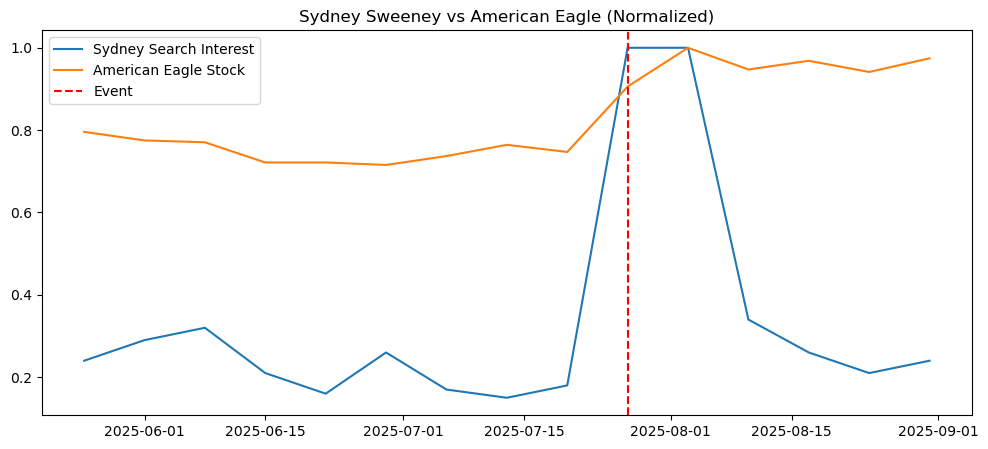

In [17]:
import matplotlib.pyplot as plt

merged["trend_norm"] = merged["Sydney Sweeney"] / merged["Sydney Sweeney"].max()
merged["stock_norm"] = merged["Close"] / merged["Close"].max()

plt.figure(figsize=(12,5))

plt.plot(merged["Time"], merged["trend_norm"], label="Sydney Search Interest")
plt.plot(merged["Time"], merged["stock_norm"], label="American Eagle Stock")

event = pd.to_datetime("2025-07-27")
plt.axvline(event, color="red", linestyle="--", label="Event")

plt.legend()
plt.title("Sydney Sweeney vs American Eagle (Normalized)")
plt.show()

In [18]:
from scipy.stats import ttest_ind
import pandas as pd

event = pd.to_datetime("2025-07-27")

before = merged[merged["Time"] < event]["Close"]
after = merged[merged["Time"] >= event]["Close"]

print("Before size:", len(before))
print("After size:", len(after))

t_stat, p_value = ttest_ind(before, after, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

Before size: 9
After size: 6
T-stat: -12.739718922249498
P-value: 2.0883966973433275e-07


Although the t-test suggests a statistically significant difference in stock prices before and after the event (p < 0.001), the result should be interpreted with caution due to the small sample size and underlying price trends. The observed difference may reflect general market movement rather than a direct causal impact of the event.

In [19]:
merged["Return"] = merged["Close"].pct_change()
merged = merged.dropna()
X = merged[["Sydney Sweeney"]]   
y = merged["Return"]             

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R^2:", model.score(X, y))

Coefficient: 0.001980092647071573
Intercept: -0.05103362872104224
R^2: 0.6349434342264526


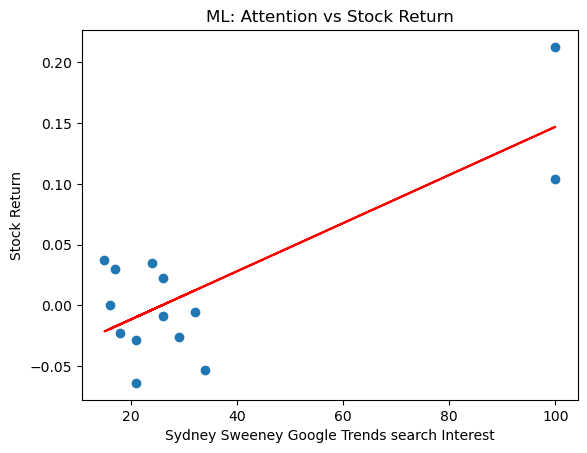

In [23]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.plot(X, model.predict(X), color="red")

plt.xlabel("Sydney Sweeney Google Trends search Interest")
plt.ylabel("Stock Return")
plt.title("ML: Attention vs Stock Return")

plt.show()